In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, GridSearchCV, KFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import random
random.seed(42)
np.random.seed(42)

# Ladda in data

In [ ]:
data = pd.read_csv("data/housing.csv")
df = data.copy()

target_column_name = "median_house_value"
feature_column_names = [col for col in df.columns if col != target_column_name]

X_full = df[feature_column_names]
y_full = df[target_column_name]

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


# EDA

In [ ]:
#print(df.head(10))
print(df.info())

In [3]:
print("Saknade värden per kolumn")
print(df.isna().sum())

Saknade värden per kolumn
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


207 ***Saknade värden*** identifierades i total_bedrooms, dem hanteras längre ned med SimpleImputer, stategy = median

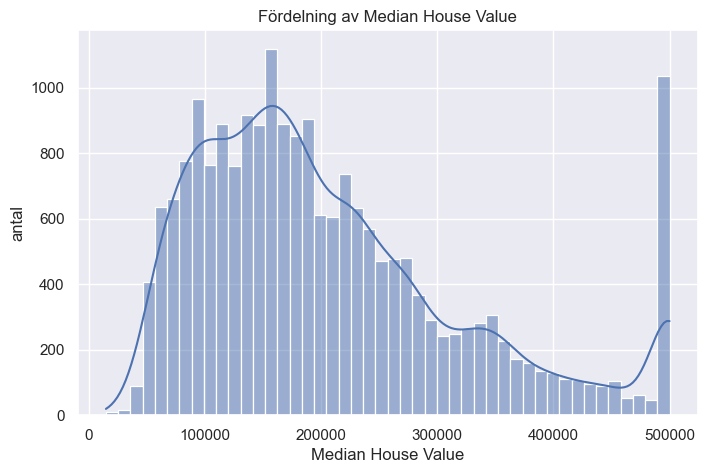

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["median_house_value"],
    kde=True
)

plt.title("Fördelning av Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("antal")

plt.show()

Fördelningen är högerskev och innehåller vissa extremvärden. Många områden ligger i ett lägre till medelhögt prisspan medan vissa områden har mycket höga bostadsvärden. Detta kan påverka regressionens felmått och modellens känslighet för outliers

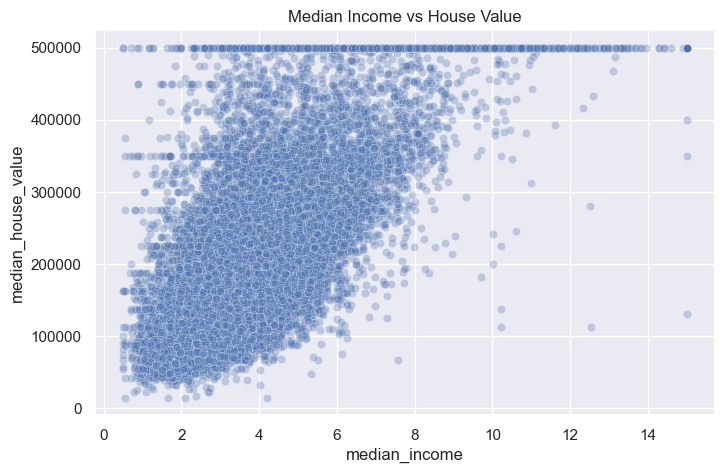

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.3
)

plt.title("Median Income vs House Value")
plt.show()

Det finns en tydligt poistiv relation mellan medianinkomst och bostadsvärde. Områden med högre medianinkomst tenderar att ha högre bostadspriser. Detta antyder att median_income kan komma att bli en viktig feature för modellen.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42
)

In [7]:
categorical_features = ["ocean_proximity"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]


# Preprocessing

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)], 
    remainder="drop"
    )

# Modeller

In [9]:
dummy = DummyRegressor(strategy="mean")

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingRegressor(
    random_state=42
)

# Pipelines & modellträning

In [10]:
pipe_dummy = Pipeline([
    ("preprocess", preprocess),
    ("model", dummy)
])

pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", lr)
])

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("model", rf)
])

pipe_gb = Pipeline([
    ("preprocess", preprocess),
    ("model", gb)
])

pipe_dummy.fit(X_train, y_train)
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [11]:
pred_dummy = pipe_dummy.predict(X_test)
pred_lr = pipe_lr.predict(X_test)
pred_rf = pipe_rf.predict(X_test)
pred_gb = pipe_gb.predict(X_test)

# Metrics funktion

In [12]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {"model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [13]:
initial_results = []

initial_results.append(
    evaluate_model(
        y_test,
        pred_dummy,
        "Dummy"
    )
)

initial_results.append(
    evaluate_model(
        y_test,
        pred_lr,
        "Linear Regression"
    )
)

initial_results.append(
    evaluate_model(
        y_test,
        pred_rf,
        "Random Forest"
    )
)

initial_results.append(
    evaluate_model(
        y_test,
        pred_gb,
        "Gradient Boosting"
    )
)

# Modelljämförelse

In [14]:
initial_results_df = pd.DataFrame(initial_results)

display(initial_results_df.sort_values("RMSE"))

,model,RMSE,MAE,R2
2,Random Forest,48721.968199,31435.282816,0.818848
3,Gradient Boosting,55903.124191,38278.148174,0.761513
1,Linear Regression,70059.193339,50670.489236,0.625438
0,Dummy,114485.635431,90606.854900,-0.000219


Ensamble modellerna presterade bäst på datasetet. Random forest gav lägst RMSE och högst R^2, vilket tyder på att modellen fångar icke-linjära samband bättre än linjär regression. Gradient boosting presterade också bra men något sämmre än Random forest. DummyRegressor användes som baseline och presterade betydligt sämre än samtliga ML-modeller. Det tyder på att modellerna faktiskt lär sig relevanta mönster från datan.

# Optimering

In [ ]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

def run_grid_search(pipeline: Pipeline, param_grid: dict, model_name: str) -> GridSearchCV:

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_strategy,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print(f"\n===  {model_name} ===")
    print("Best CV RMSE:", -grid_search.best_score_)
    print("Best params:", grid_search.best_params_)

    return grid_search

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05 , 0.1],
    "model__max_depth": [2 , 3]
}


In [ ]:
gb_grid = run_grid_search(
    pipe_gb,
    gb_param_grid,
    "Gradient Boosting"
)

best_gb_model = gb_grid.best_estimator_

#print(best_gb_model)



===  Gradient Boosting ===
Best CV RMSE: 51732.54710424243
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

===  Random forest ===
Best CV RMSE: 49309.54130632225
Best params: {'model__max_depth': 20, 'model__n_estimators': 200}


In [ ]:
final_predictions_gb = best_gb_model.predict(X_test)

(16512, 9)
(16512,)


# Slutresultat på testdata

In [19]:

final_results = []

final_results.append(
    evaluate_model(
        y_test,
        pred_dummy,
        "Dummy"
    )
)

final_results.append(
    evaluate_model(
        y_test,
        pred_lr,
        "Linear Regression"
    )
)

final_results.append(
    evaluate_model(
        y_test,
        pred_rf,
        "Random forest"
    )
)

final_results.append(
    evaluate_model(
        y_test,
        pred_gb,
        "Gradient Boosting"
    )
)

final_model_gb = evaluate_model(
    y_test,
    final_predictions_gb,
    "Tuned Gradient Boosting"
)

final_results.append(final_model_gb)
final_results_df = pd.DataFrame(final_results)
display(final_results_df.sort_values("RMSE"))

,model,RMSE,MAE,R2
2,Random forest,48721.968199,31435.282816,0.818848
4,Tuned Gradient Boosting,52142.797906,35477.862046,0.792517
3,Gradient Boosting,55903.124191,38278.148174,0.761513
1,Linear Regression,70059.193339,50670.489236,0.625438
0,Dummy,114485.635431,90606.854900,-0.000219
